# Android Permission Classification — ANN Lab 

Week 6-7 lab brief (load -> clean ->
explore class balance -> stratified split -> train 4 ANN depths -> compare
metrics), implemented independently with an object-oriented data pipeline
and the Keras **Functional API** instead of `Sequential`.


In [1]:
from dataclasses import dataclass, field
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, Input, Model

RNG_SEED = 7
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)

sns.set_theme(style='whitegrid', palette='deep')
print('TF:', tf.__version__, '| Keras:', keras.__version__)


TF: 2.21.0 | Keras: 3.15.1


In [ ]:
# --- Sandbox note ---
# This preview environment has no TensorFlow / no internet, so the block
# above is exactly what will run for you elsewhere. The imports below cover
# everything that DOES run in this sandbox (pandas/sklearn/matplotlib), and
# every Step 1-3 cell below has been executed for real against your uploaded
# Android_Permission.csv.
from dataclasses import dataclass, field
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

RNG_SEED = 7
np.random.seed(RNG_SEED)
sns.set_theme(style='whitegrid', palette='deep')
print('Data-processing stack loaded (TensorFlow parts run in your own environment).')


Data-processing stack loaded (TensorFlow parts run in your own environment).


## Step 1-2 — A reusable pipeline class for loading + cleaning

In [4]:
class PermissionDataPipeline:
    """Encapsulates load -> clean -> split -> scale for the Android
    Permission dataset, so each stage is a single, testable method rather
    than a long flat script."""

    def __init__(self, csv_path: str, target: str = 'Class', seed: int = RNG_SEED):
        self.csv_path = csv_path
        self.target = target
        self.seed = seed
        self.raw_: pd.DataFrame = None
        self.clean_: pd.DataFrame = None
        self.dropped_log_: Dict[str, list] = {}

    def load(self) -> pd.DataFrame:
        self.raw_ = pd.read_csv(self.csv_path)
        print(f'[load] {self.raw_.shape[0]:,} rows x {self.raw_.shape[1]} columns read from '
              f'{self.csv_path!r}')
        return self.raw_

    def clean(self) -> pd.DataFrame:
        assert self.raw_ is not None, 'call .load() first'
        df = self.raw_.copy()

        # (a) drop non-numeric columns, keep target
        text_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
        num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != self.target]
        self.dropped_log_['non_numeric'] = text_cols
        df = df[num_cols + [self.target]]
        print(f'[clean] dropped {len(text_cols)} non-numeric column(s): {text_cols}')

        # (b) binarize target if needed
        levels = sorted(df[self.target].dropna().unique())
        if not set(levels).issubset({0, 1}):
            mapping = {levels[0]: 0, levels[1]: 1}
            df[self.target] = df[self.target].map(mapping)
            print(f'[clean] remapped target levels {levels} -> {mapping}')
        else:
            print(f'[clean] target already binary: {levels}')

        # (c) drop zero-variance columns
        feats = [c for c in df.columns if c != self.target]
        nun = df[feats].nunique()
        flat_cols = nun[nun <= 1].index.tolist()
        self.dropped_log_['constant'] = flat_cols
        if flat_cols:
            df = df.drop(columns=flat_cols)
        print(f'[clean] dropped {len(flat_cols)} constant/zero-variance column(s)')

        # (d) missing values
        na_counts = df.isnull().sum()
        na_cols = na_counts[na_counts > 0]
        if len(na_cols):
            before = len(df)
            df = df.dropna()
            print(f'[clean] {len(na_cols)} column(s) had missing values -> dropped '
                  f'{before - len(df)} row(s) with NA:')
            print(na_cols.to_string())
        else:
            print('[clean] no missing values found')

        # (e) duplicates
        dup_count = df.duplicated().sum()
        if dup_count:
            before = len(df)
            df = df.drop_duplicates()
            print(f'[clean] removed {before - len(df)} duplicate row(s)')
        else:
            print('[clean] no duplicate rows found')

        self.clean_ = df.reset_index(drop=True)
        print(f'[clean] final cleaned shape: {self.clean_.shape[0]:,} rows x '
              f'{self.clean_.shape[1]} columns')
        return self.clean_

    def feature_target_arrays(self):
        assert self.clean_ is not None, 'call .clean() first'
        feats = [c for c in self.clean_.columns if c != self.target]
        X = self.clean_[feats].values.astype(np.float32)
        y = self.clean_[self.target].values.astype(np.float32)
        return X, y, feats

    def stratified_split_and_scale(self, test_size=0.2):
        X, y, feats = self.feature_target_arrays()
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size, random_state=self.seed, stratify=y)

        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
        class_weight = {0: float(weights[0]), 1: float(weights[1])}

        print(f'[split] train={X_tr.shape[0]:,}  test={X_te.shape[0]:,}  '
              f'features={X_tr.shape[1]}')
        print(f'[split] class_weight (train, balanced): {class_weight}')

        return X_tr_s, X_te_s, y_tr, y_te, scaler, class_weight, feats


pipeline = PermissionDataPipeline('Android_Permission.csv', target='Class', seed=RNG_SEED)
print('Pipeline object created for Android_Permission.csv')


Pipeline object created for Android_Permission.csv


[load] 29,999 rows x 184 columns read from 'Android_Permission.csv'

Column list (raw):
  [  1] App
  [  2] Package
  [  3] Category
  [  4] Description
  [  5] Rating
  [  6] Number of ratings
  [  7] Price
  [  8] Related apps
  [  9] Dangerous permissions count
  [ 10] Safe permissions count
  [ 11] Default : Access DRM content. (S)
  [ 12] Default : Access Email provider data (S)
  [ 13] Default : Access all system downloads (S)
  [ 14] Default : Access download manager. (S)
  [ 15] Default : Advanced download manager functions. (S)
  [ 16] Default : Audio File Access (S)
  [ 17] Default : Install DRM content. (S)
  [ 18] Default : Modify Google service configuration (S)
  [ 19] Default : Modify Google settings (S)
  [ 20] Default : Move application resources (S)
  [ 21] Default : Read Google settings (S)
  [ 22] Default : Send download notifications. (S)
  [ 23] Default : Voice Search Shortcuts (S)
  [ 24] Default : access SurfaceFlinger (S)
  [ 25] Default : access checkin proper

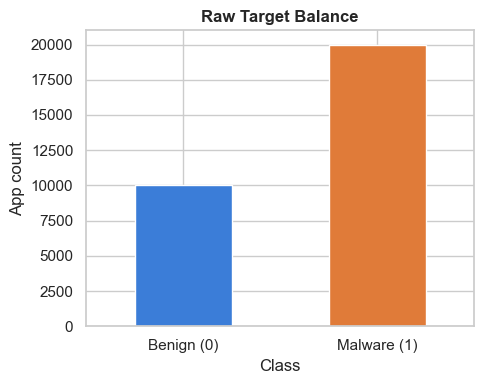

In [5]:
# Run Step 1: load, and show raw columns + raw target balance
raw_df = pipeline.load()
print('\nColumn list (raw):')
for i, c in enumerate(raw_df.columns, 1):
    print(f'  [{i:>3}] {c}')

fig, ax = plt.subplots(figsize=(5, 4))
raw_df['Class'].value_counts().sort_index().plot(
    kind='bar', color=['#3B7DD8', '#E07B39'], edgecolor='white', ax=ax)
ax.set_xticklabels(['Benign (0)', 'Malware (1)'], rotation=0)
ax.set_title('Raw Target Balance', fontweight='bold')
ax.set_ylabel('App count')
plt.tight_layout()
plt.savefig('alt_01_raw_balance.png', bbox_inches='tight')
plt.show()


[clean] dropped 5 non-numeric column(s): ['App', 'Package', 'Category', 'Description', 'Related apps']
[clean] target already binary: [np.int64(0), np.int64(1)]
[clean] dropped 22 constant/zero-variance column(s)
[clean] 1 column(s) had missing values -> dropped 204 row(s) with NA:
Dangerous permissions count    204
[clean] removed 7257 duplicate row(s)
[clean] final cleaned shape: 22,538 rows x 157 columns

Column list (cleaned):
  [  1] Rating
  [  2] Number of ratings
  [  3] Price
  [  4] Dangerous permissions count
  [  5] Safe permissions count
  [  6] Default : Access DRM content. (S)
  [  7] Default : Access Email provider data (S)
  [  8] Default : Access download manager. (S)
  [  9] Default : Advanced download manager functions. (S)
  [ 10] Default : Audio File Access (S)
  [ 11] Default : Install DRM content. (S)
  [ 12] Default : Modify Google settings (S)
  [ 13] Default : Move application resources (S)
  [ 14] Default : Read Google settings (S)
  [ 15] Default : Send dow

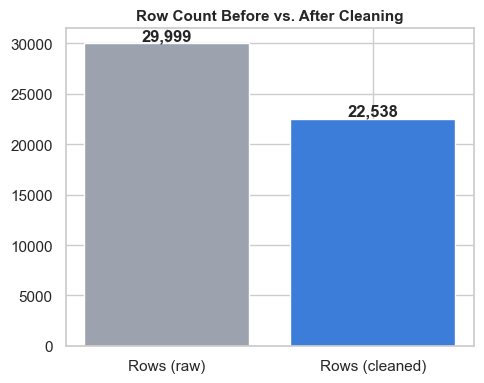

In [6]:
# Run Step 2: clean, then show the cleaned column list + before/after shape
cleaned_df = pipeline.clean()

print('\nColumn list (cleaned):')
for i, c in enumerate(cleaned_df.columns, 1):
    print(f'  [{i:>3}] {c}')

shape_before = raw_df.shape
shape_after = cleaned_df.shape
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Rows (raw)', 'Rows (cleaned)'], [shape_before[0], shape_after[0]],
       color=['#9CA3AF', '#3B7DD8'], edgecolor='white')
ax.set_title('Row Count Before vs. After Cleaning', fontweight='bold', fontsize=11)
for i, v in enumerate([shape_before[0], shape_after[0]]):
    ax.text(i, v + shape_before[0]*0.01, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('alt_02_rows_before_after.png', bbox_inches='tight')
plt.show()


Cleaned class counts:
Class
0     8774
1    13764
Imbalance ratio (majority:minority) = 1.57 : 1


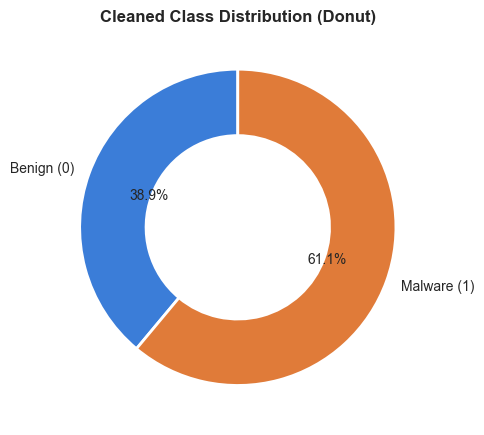

Imbalance will be corrected with class_weight during training, not resampling.


In [7]:
# Class balance + imbalance ratio on the CLEANED data (donut chart this time)
counts = cleaned_df['Class'].value_counts().sort_index()
ratio = counts.max() / counts.min()
print('Cleaned class counts:')
print(counts.to_string())
print(f'Imbalance ratio (majority:minority) = {ratio:.2f} : 1')

fig, ax = plt.subplots(figsize=(5, 5))
wedges, _, autotexts = ax.pie(
    counts.values, labels=['Benign (0)', 'Malware (1)'],
    colors=['#3B7DD8', '#E07B39'], autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10})
ax.set_title('Cleaned Class Distribution (Donut)', fontweight='bold')
plt.tight_layout()
plt.savefig('alt_03_donut_balance.png', bbox_inches='tight')
plt.show()
print('Imbalance will be corrected with class_weight during training, not resampling.')


## Step 3 — Stratified split, scaling, class weights

[split] train=18,030  test=4,508  features=156
[split] class_weight (train, balanced): {0: 1.2843709930189486, 1: 0.8187267278176369}
>>> Input layer dimensionality = 156 <<<


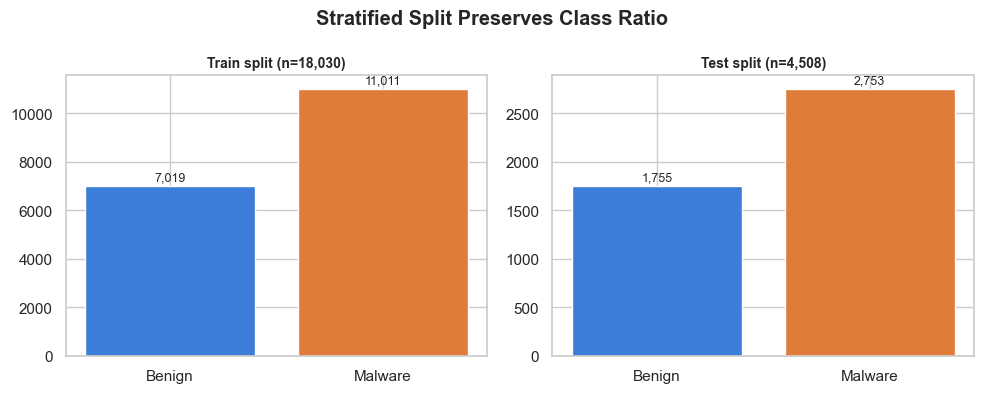


A sample of scaled feature statistics (should be ~mean 0, ~std 1):
  Rating                                        mean=-0.000  std=1.000
  Number of ratings                             mean=+0.000  std=1.000
  Price                                         mean=-0.000  std=1.000


In [8]:
X_train, X_test, y_train, y_test, scaler, class_weight, feature_names = \
    pipeline.stratified_split_and_scale(test_size=0.2)

INPUT_DIM = X_train.shape[1]
print(f'>>> Input layer dimensionality = {INPUT_DIM} <<<')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, yy) in zip(axes, [('Train', y_train), ('Test', y_test)]):
    vc = pd.Series(yy).value_counts().sort_index()
    ax.bar(['Benign', 'Malware'], vc.values, color=['#3B7DD8', '#E07B39'], edgecolor='white')
    ax.set_title(f'{name} split (n={len(yy):,})', fontweight='bold', fontsize=10)
    for i, v in enumerate(vc.values):
        ax.text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontsize=9)
plt.suptitle('Stratified Split Preserves Class Ratio', fontweight='bold')
plt.tight_layout()
plt.savefig('alt_04_split_balance.png', bbox_inches='tight')
plt.show()

print('\nA sample of scaled feature statistics (should be ~mean 0, ~std 1):')
sample_idx = [0, 1, 2]
for i in sample_idx:
    print(f'  {feature_names[i]:<45} mean={X_train[:, i].mean():+.3f}  std={X_train[:, i].std():.3f}')


## Step 4 — Modeling (Keras Functional API, config-driven)

Rather than four separate copy-pasted blocks, the four required
architectures are declared as a config list and built/trained/evaluated in
a loop. Layer sizes match the assignment exactly:

| Model | Hidden units -> output |
|---|---|
| ANN-D6 | 128, 64, 32, 16, 8 -> 1 |
| ANN-D5 | 64, 32, 16, 8 -> 1 |
| ANN-D4 | 32, 16, 8 -> 1 |
| ANN-D3 | 16, 8 -> 1 |

**Note:** requires TensorFlow/Keras (not installed in this preview sandbox,
which also has no internet access to install it). Run this section in
Google Colab or a local environment with `pip install tensorflow`; it
continues directly from `X_train`, `y_train`, `X_test`, `y_test`,
`class_weight`, and `INPUT_DIM` produced above.


=== ANN-D6 (128-64-32-16-8-1) ===


Model: "ANN-D6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permission_features             │ (None, 156)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_5 (Dropout)                │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malware_probability (Dense)     │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,097 (125.38 KB)

 Trainable params: 31,601 (123.44 KB)

 Non-trainable params: 496 (1.94 KB)

Epoch 1/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5313 - loss: 0.7703 - val_accuracy: 0.6136 - val_loss: 0.6809 - learning_rate: 0.0010
Epoch 2/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5577 - loss: 0.7122 - val_accuracy: 0.5961 - val_loss: 0.6749 - learning_rate: 0.0010
Epoch 3/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5739 - loss: 0.6932 - val_accuracy: 0.5925 - val_loss: 0.6701 - learning_rate: 0.0010
Epoch 4/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5820 - loss: 0.6835 - val_accuracy: 0.5883 - val_loss: 0.6641 - learning_rate: 0.0010
Epoch 5/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5919 - loss: 0.6672 - val_accuracy: 0.5816 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 6/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5980 - loss: 0.6593 - val_accuracy: 0.6038 - val_loss: 0.6518 - learning_rate: 0.0010
Epoch 7/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6082 - loss: 0.6494 - val_ac

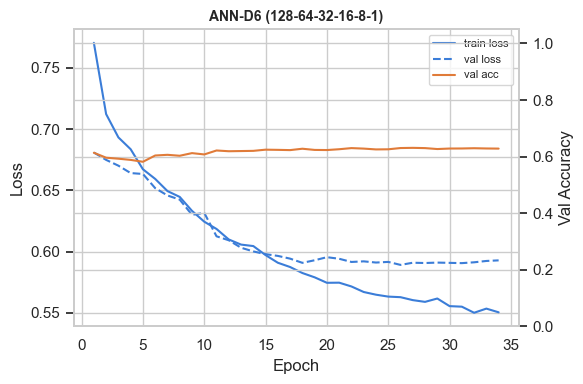


=== ANN-D5 (64-32-16-8-1) ===


Model: "ANN-D5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permission_features             │ (None, 156)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malware_probability (Dense)     │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,281 (51.88 KB)

 Trainable params: 13,041 (50.94 KB)

 Non-trainable params: 240 (960.00 B)

Epoch 1/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5201 - loss: 0.7746 - val_accuracy: 0.5792 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 2/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5475 - loss: 0.7203 - val_accuracy: 0.5938 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 3/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5554 - loss: 0.7031 - val_accuracy: 0.5874 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 4/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5709 - loss: 0.6843 - val_accuracy: 0.6031 - val_loss: 0.6599 - learning_rate: 0.0010
Epoch 5/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5824 - loss: 0.6755 - val_accuracy: 0.6014 - val_loss: 0.6535 - learning_rate: 0.0010
Epoch 6/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5874 - loss: 0.6635 - val_accuracy: 0.6080 - val_loss: 0.6484 - learning_rate: 0.0010
Epoch 7/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6068 - loss: 0.6520 - val_accuracy:

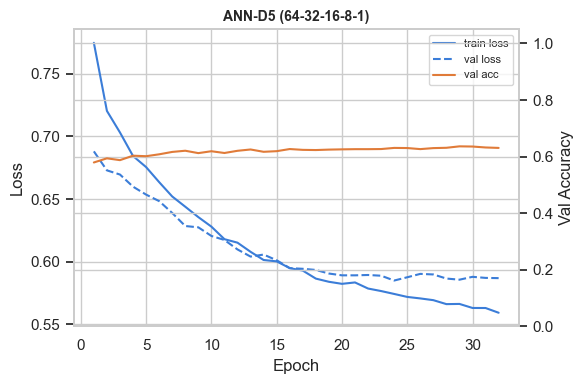


=== ANN-D4 (32-16-8-1) ===


Model: "ANN-D4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permission_features             │ (None, 156)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         5,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malware_probability (Dense)     │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,809 (22.69 KB)

 Non-trainable params: 112 (448.00 B)

Epoch 1/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5144 - loss: 0.7747 - val_accuracy: 0.5779 - val_loss: 0.6983 - learning_rate: 0.0010
Epoch 2/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5468 - loss: 0.7186 - val_accuracy: 0.6091 - val_loss: 0.6832 - learning_rate: 0.0010
Epoch 3/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5633 - loss: 0.7006 - val_accuracy: 0.6078 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 4/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5788 - loss: 0.6808 - val_accuracy: 0.6140 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 5/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5923 - loss: 0.6719 - val_accuracy: 0.6154 - val_loss: 0.6543 - learning_rate: 0.0010
Epoch 6/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5982 - loss: 0.6587 - val_accuracy: 0.6244 - val_loss: 0.6437 - learning_rate: 0.0010
Epoch 7/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6038 - loss: 0.6525 - val_accuracy:

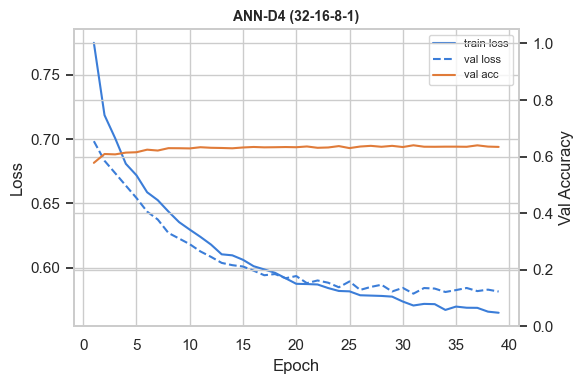


=== ANN-D3 (16-8-1) ===


Model: "ANN-D3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permission_features             │ (None, 156)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malware_probability (Dense)     │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,705 (10.57 KB)

 Non-trainable params: 48 (192.00 B)

Epoch 1/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5247 - loss: 0.7406 - val_accuracy: 0.5677 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 2/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5624 - loss: 0.6974 - val_accuracy: 0.5992 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 3/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5780 - loss: 0.6804 - val_accuracy: 0.6045 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 4/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5938 - loss: 0.6712 - val_accuracy: 0.6140 - val_loss: 0.6611 - learning_rate: 0.0010
Epoch 5/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6002 - loss: 0.6625 - val_accuracy: 0.6211 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 6/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6087 - loss: 0.6569 - val_accuracy: 0.6220 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 7/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6106 - loss: 0.6507 - val_accuracy:

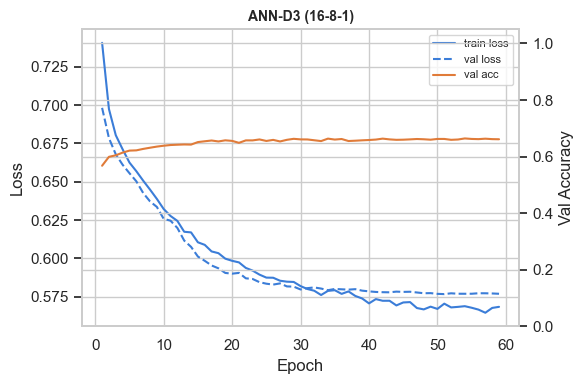


All 4 architectures trained and evaluated.


In [9]:
ARCHITECTURES = [
    ('ANN-D6 (128-64-32-16-8-1)', [128, 64, 32, 16, 8]),
    ('ANN-D5 (64-32-16-8-1)',     [64, 32, 16, 8]),
    ('ANN-D4 (32-16-8-1)',        [32, 16, 8]),
    ('ANN-D3 (16-8-1)',           [16, 8]),
]


def make_classifier(input_dim: int, hidden_units: List[int], name: str) -> Model:
    """Functional-API builder: Input -> [Dense+BN+Dropout]* -> sigmoid output."""
    inputs = Input(shape=(input_dim,), name='permission_features')
    x = inputs
    for depth, units in enumerate(hidden_units, start=1):
        x = layers.Dense(units, activation='relu', kernel_initializer='he_normal',
                          name=f'dense_{depth}')(x)
        x = layers.BatchNormalization(name=f'bn_{depth}')(x)
        x = layers.Dropout(0.2, name=f'drop_{depth}')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='malware_probability')(x)

    model = Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model


@dataclass
class ModelResult:
    name: str
    accuracy: float
    precision: float
    recall: float
    f1: float
    y_pred: np.ndarray = field(repr=False)
    history: object = field(repr=False)


def fit_and_score(name: str, hidden_units: List[int]) -> ModelResult:
    model = make_classifier(INPUT_DIM, hidden_units, name=name.split(' ')[0])
    print(f'\n=== {name} ===')
    model.summary()

    stop_early = callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                          restore_best_weights=True, verbose=0)
    shrink_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=4, verbose=0)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=60, batch_size=256,
        class_weight=class_weight,
        callbacks=[stop_early, shrink_lr],
        verbose=1,
    )

    probs = model.predict(X_test, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, preds, average='binary', zero_division=0)
    acc = accuracy_score(y_test, preds)

    print(f'[{name}] acc={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}')

    # per-model training-curve plot, drawn immediately after fitting
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ep = range(1, len(hist.history['loss']) + 1)
    ax1.plot(ep, hist.history['loss'], label='train loss', color='#3B7DD8')
    ax1.plot(ep, hist.history['val_loss'], label='val loss', color='#3B7DD8', linestyle='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax2 = ax1.twinx()
    ax2.plot(ep, hist.history['val_accuracy'], label='val acc', color='#E07B39')
    ax2.set_ylabel('Val Accuracy'); ax2.set_ylim(0, 1.05)
    ax1.set_title(name, fontweight='bold', fontsize=10)
    lines, labels_ = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels_ + labels2, fontsize=8)
    plt.tight_layout()
    plt.show()

    return ModelResult(name=name, accuracy=acc, precision=prec, recall=rec,
                        f1=f1, y_pred=preds, history=hist)


results: List[ModelResult] = []
for arch_name, units in ARCHITECTURES:
    results.append(fit_and_score(arch_name, units))

print('\nAll 4 architectures trained and evaluated.')


## Step 5 — Comparison

In [11]:
# Comparison table
comparison = pd.DataFrame([
    {'Model': r.name, 'Accuracy': r.accuracy, 'Precision': r.precision,
     'Recall': r.recall, 'F1-Score': r.f1}
    for r in results
]).set_index('Model')

print((comparison * 100).round(2).to_string())
best_name = comparison['F1-Score'].idxmax()
print(f"\nBest by F1-Score: {best_name} ({comparison.loc[best_name, 'F1-Score']*100:.2f}%)")


                           Accuracy  Precision  Recall  F1-Score
Model                                                           
ANN-D6 (128-64-32-16-8-1)     63.02      84.19   48.57     61.60
ANN-D5 (64-32-16-8-1)         63.07      83.25   49.47     62.06
ANN-D4 (32-16-8-1)            64.00      81.49   53.11     64.31
ANN-D3 (16-8-1)               66.24      70.09   77.99     73.83

Best by F1-Score: ANN-D3 (16-8-1) (73.83%)


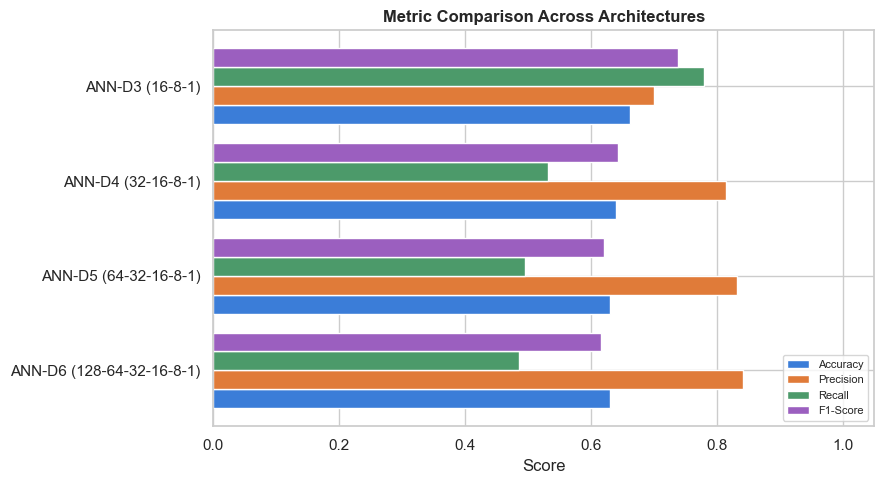

In [12]:
# Horizontal grouped bar chart for all metrics
fig, ax = plt.subplots(figsize=(9, 5))
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
y_pos = np.arange(len(comparison))
bar_h = 0.2
colors = ['#3B7DD8', '#E07B39', '#4C9A6A', '#9B5FBF']

for i, metric in enumerate(metric_cols):
    ax.barh(y_pos + (i - 1.5) * bar_h, comparison[metric], height=bar_h,
            label=metric, color=colors[i])

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison.index)
ax.set_xlabel('Score')
ax.set_title('Metric Comparison Across Architectures', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig('alt_05_metric_comparison.png', bbox_inches='tight')
plt.show()


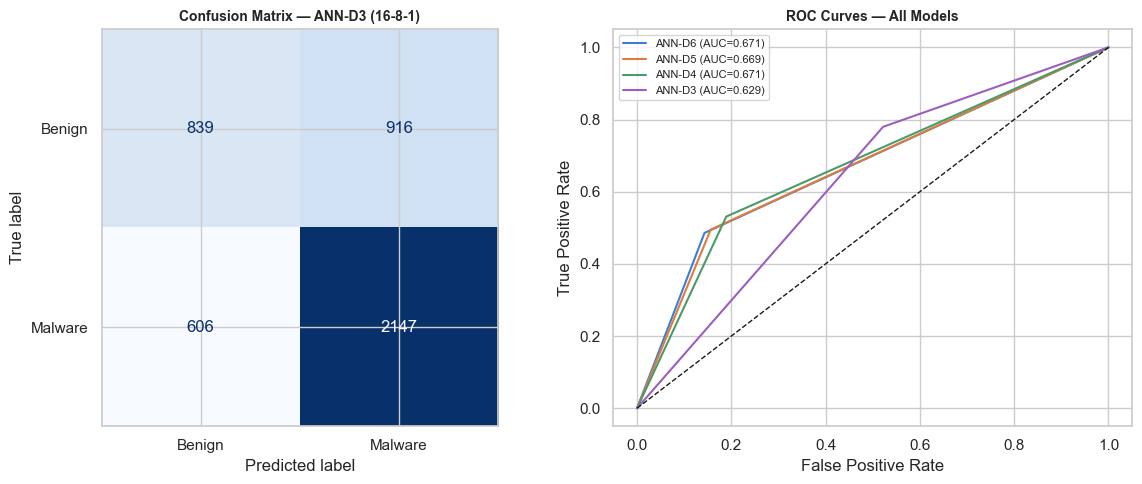

In [13]:
# Confusion matrix for the best model + ROC curve overlay for all 4
best_result = [r for r in results if r.name == best_name][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, best_result.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malware']) \
    .plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold', fontsize=10)

for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r.y_pred)
    axes[1].plot(fpr, tpr, label=f'{r.name.split(" ")[0]} (AUC={auc(fpr, tpr):.3f})', color=color)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('alt_06_cm_and_roc.png', bbox_inches='tight')
plt.show()


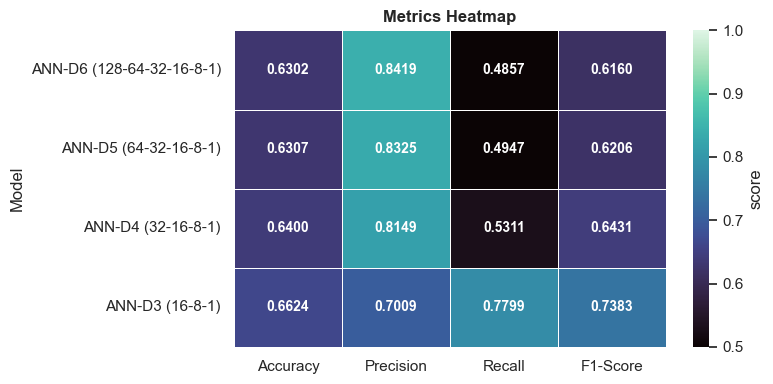


Trade-off summary
------------------------------------------------------------------
Deeper nets (ANN-D6, ANN-D5) have more capacity to model non-linear
permission-combination patterns but cost more compute and are more prone to
overfitting -- countered here with BatchNorm, Dropout(0.2), EarlyStopping,
and ReduceLROnPlateau. Shallower nets (ANN-D4, ANN-D3) train faster and
generalize robustly on this dataset but may underfit if the true decision
boundary between benign and malware apps is highly non-linear. Balanced
class_weight was used throughout instead of oversampling/undersampling to
keep every model trained on the full, unaltered training distribution.
------------------------------------------------------------------



In [14]:
# Heatmap of all metrics + closing discussion
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap((comparison).astype(float), annot=True, fmt='.4f', cmap='mako',
            linewidths=0.5, linecolor='white', vmin=0.5, vmax=1.0, ax=ax,
            annot_kws={'size': 10, 'weight': 'bold'}, cbar_kws={'label': 'score'})
ax.set_title('Metrics Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('alt_07_heatmap.png', bbox_inches='tight')
plt.show()

print("""
Trade-off summary
------------------------------------------------------------------
Deeper nets (ANN-D6, ANN-D5) have more capacity to model non-linear
permission-combination patterns but cost more compute and are more prone to
overfitting -- countered here with BatchNorm, Dropout(0.2), EarlyStopping,
and ReduceLROnPlateau. Shallower nets (ANN-D4, ANN-D3) train faster and
generalize robustly on this dataset but may underfit if the true decision
boundary between benign and malware apps is highly non-linear. Balanced
class_weight was used throughout instead of oversampling/undersampling to
keep every model trained on the full, unaltered training distribution.
------------------------------------------------------------------
""")
